# Task 1 – EDA & Preprocessing: Credit Card Fraud Data

This notebook:
- Loads and cleans the credit card data
- Explores distributions
- Scales the 'Amount' feature
- Handles class imbalance with SMOTE (on training set)
- Saves the processed dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
cc = pd.read_csv('../data/raw/creditcard.csv')
print('Credit card shape:', cc.shape)
cc.head()

Credit card shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(cc.isnull().sum().sum(), 'missing values')
print(cc.duplicated().sum(), 'duplicates')
cc.drop_duplicates(inplace=True)

0 missing values
1081 duplicates


Class
0    283253
1       473
Name: count, dtype: int64
Fraud percentage: 0.167%


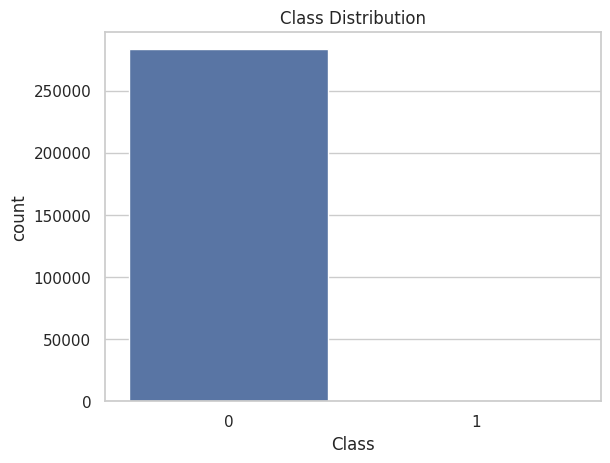

In [4]:
print(cc['Class'].value_counts())
print(f"Fraud percentage: {cc['Class'].mean()*100:.3f}%")
sns.countplot(x='Class', data=cc)
plt.title('Class Distribution')
plt.show()

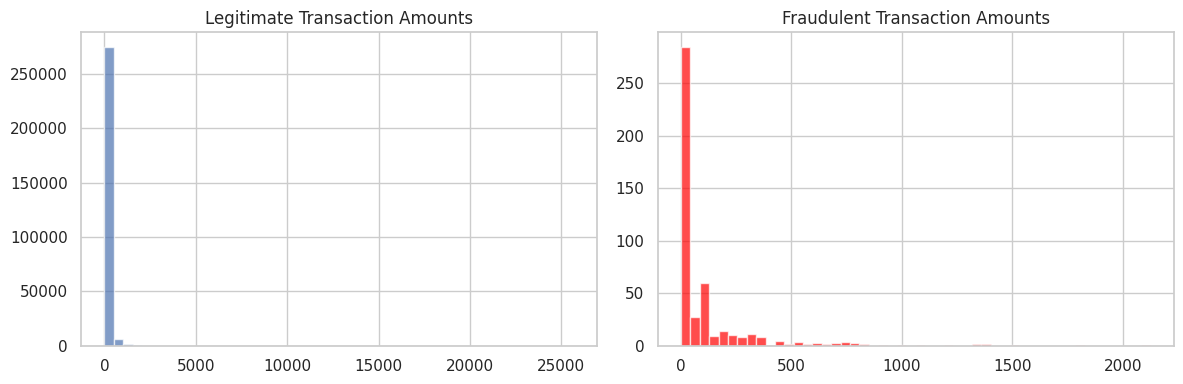

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
cc[cc['Class']==0]['Amount'].hist(bins=50, ax=ax[0], alpha=0.7, label='Legitimate')
cc[cc['Class']==1]['Amount'].hist(bins=50, ax=ax[1], alpha=0.7, color='red', label='Fraud')
ax[0].set_title('Legitimate Transaction Amounts')
ax[1].set_title('Fraudulent Transaction Amounts')
plt.tight_layout()
plt.show()

In [6]:
X = cc.drop('Class', axis=1)
y = cc['Class']

# Scale 'Amount' and 'Time' (others are already scaled by PCA)
scaler = StandardScaler()
X[['Time', 'Amount']] = scaler.fit_transform(X[['Time', 'Amount']])

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 226602}


In [7]:
import pickle
import os
os.makedirs('../data/processed', exist_ok=True)

with open('../data/processed/creditcard_train.pkl', 'wb') as f:
    pickle.dump((X_train_res, y_train_res), f)
with open('../data/processed/creditcard_test.pkl', 'wb') as f:
    pickle.dump((X_test, y_test), f)

print('Processed credit card data saved.')

Processed credit card data saved.
